# CIFAR-10 Core Training Pipeline

仅保留主线：导入、配置、数据、4组实验训练、结果对比。


In [1]:
import os
import random
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

sys.path.append(os.path.abspath("../../src"))
from cauchy_res_mixer import CauchyCNN, ImprovedCauchyCNN, evaluate, train_one_epoch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
@dataclass
class Config:
    batch_size: int = 128
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 2
    base_channels: int = 64

cfg_debug = Config(
    batch_size=64,
    epochs=3,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=0,
    base_channels=32,
)

cfg_full = Config(
    batch_size=128,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=2,
    base_channels=64,
)

debug = False
cfg = cfg_debug if debug else cfg_full

experiment_grid = [
    ("standard", "relu"),
    ("standard", "cauchy"),
    ("cauchy", "relu"),
    ("cauchy", "cauchy"),
]

cfg

Config(batch_size=128, epochs=30, lr=0.001, weight_decay=0.0001, num_workers=2, base_channels=64)

In [3]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

num_classes = len(train_ds.classes)
print(f"Train={len(train_ds)}, Test={len(test_ds)}, Classes={num_classes}")


/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train=50000, Test=10000, Classes=10


In [4]:
def run_experiment(model_ctor, train_loader, test_loader, num_classes):
    criterion = nn.CrossEntropyLoss()
    results = {}

    experiment_bar = tqdm(experiment_grid, desc="Experiments", leave=True)
    for residual_mode, activation_mode in experiment_bar:
        key = f"{residual_mode}_{activation_mode}"
        experiment_bar.set_postfix_str(key)
        model = model_ctor(
            num_classes=num_classes,
            base_channels=cfg.base_channels,
            activation_mode=activation_mode,
            residual_mode=residual_mode,
        ).to(device)

        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
        )

        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "lr": [],
        }
        epoch_bar = tqdm(range(cfg.epochs), desc=f"{key}", leave=False)
        for epoch in epoch_bar:
            tr_loss, tr_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, device
            )
            te_loss, te_acc = evaluate(model, test_loader, criterion, device)
            current_lr = optimizer.param_groups[0]["lr"]

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["test_loss"].append(te_loss)
            history["test_acc"].append(te_acc)
            history["lr"].append(current_lr)
            epoch_bar.set_postfix_str(
                f"train_acc={tr_acc:.4f}, test_acc={te_acc:.4f}, lr={current_lr:.6f}"
            )

            if epoch % 10 == 0 or epoch == cfg.epochs - 1:
                print(
                    f"[{key}] epoch {epoch + 1:02d}/{cfg.epochs} | train_acc={tr_acc:.4f} test_acc={te_acc:.4f} lr={current_lr:.6f}"
                )

        results[key] = {
            "residual_mode": residual_mode,
            "activation_mode": activation_mode,
            "history": history,
            "final_test_acc": history["test_acc"][-1],
        }

    return results

In [5]:
results = run_experiment(CauchyCNN, train_loader, test_loader, num_classes)


Experiments:   0%|          | 0/4 [00:00<?, ?it/s, standard_relu]

[standard_relu] epoch 01/30 | train_acc=0.4380 test_acc=0.5589 lr=0.001000


[standard_relu] epoch 11/30 | train_acc=0.8851 test_acc=0.8744 lr=0.001000


[standard_relu] epoch 21/30 | train_acc=0.9393 test_acc=0.8955 lr=0.001000


Experiments:  25%|██▌       | 1/4 [11:44<35:12, 704.01s/it, standard_cauchy]

...

[cauchy_cauchy] epoch 01/30 | train_acc=0.2286 test_acc=0.2831 lr=0.001000


[cauchy_cauchy] epoch 11/30 | train_acc=0.6816 test_acc=0.6401 lr=0.001000


[cauchy_cauchy] epoch 21/30 | train_acc=0.8037 test_acc=0.7638 lr=0.001000


Experiments: 100%|██████████| 4/4 [1:15:07<00:00, 1126.83s/it, cauchy_cauchy]

[cauchy_cauchy] epoch 30/30 | train_acc=0.8542 test_acc=0.8049 lr=0.001000


In [6]:
def plot_results(results):
    epochs_axis = np.arange(1, cfg.epochs + 1)

    plt.figure(figsize=(13, 5))
    plt.subplot(1, 2, 1)
    for k, v in results.items():
        plt.plot(epochs_axis, v["history"]["test_loss"], label=k)
    plt.title("Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for k, v in results.items():
        plt.plot(epochs_axis, v["history"]["test_acc"], label=k)
    plt.title("Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 4))
    for k, v in results.items():
        plt.plot(epochs_axis, v["history"]["lr"], label=k)
    plt.title("Learning Rate Schedule")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    ranked = sorted(results.items(), key=lambda kv: kv[1]["final_test_acc"], reverse=True)
    labels = [k for k, _ in ranked]
    vals = [v["final_test_acc"] for _, v in ranked]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, vals)
    plt.ylim(0, 1)
    plt.title("Final Test Accuracy Ranking")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    for b, val in zip(bars, vals):
        plt.text(b.get_x() + b.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

In [7]:
rows = [
    {
        "exp": k,
        "residual_mode": v["residual_mode"],
        "activation_mode": v["activation_mode"],
        "final_test_acc": v["final_test_acc"],
    }
    for k, v in results.items()
]
rows = sorted(rows, key=lambda x: x["final_test_acc"], reverse=True)
for r in rows:
    print(r)


{'exp': 'cauchy_relu', 'residual_mode': 'cauchy', 'activation_mode': 'relu', 'final_test_acc': 0.9106}
{'exp': 'standard_relu', 'residual_mode': 'standard', 'activation_mode': 'relu', 'final_test_acc': 0.9069}
{'exp': 'standard_cauchy', 'residual_mode': 'standard', 'activation_mode': 'cauchy', 'final_test_acc': 0.8196}
{'exp': 'cauchy_cauchy', 'residual_mode': 'cauchy', 'activation_mode': 'cauchy', 'final_test_acc': 0.8049}


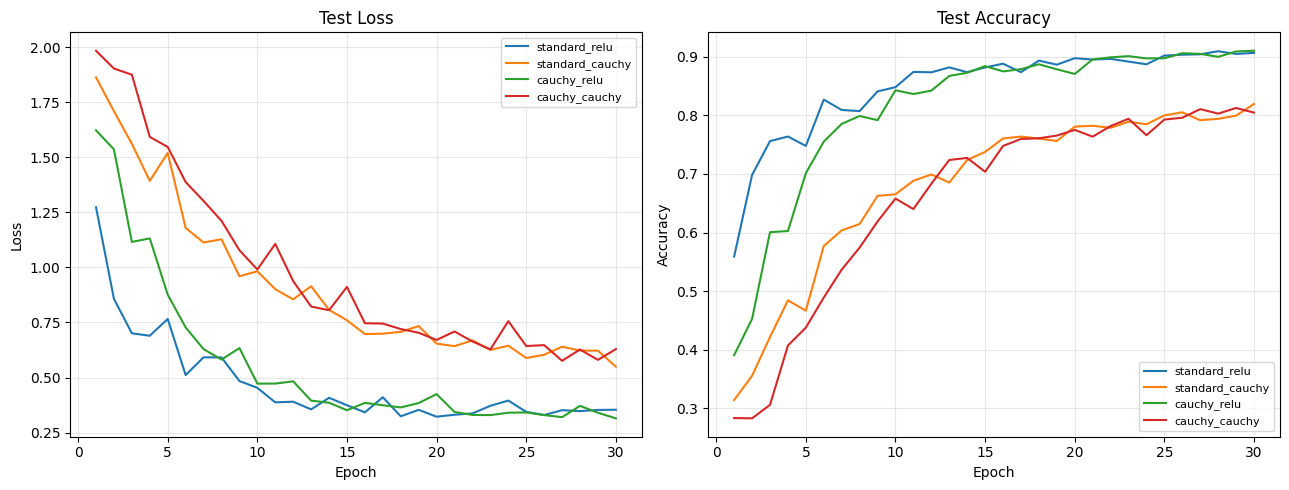

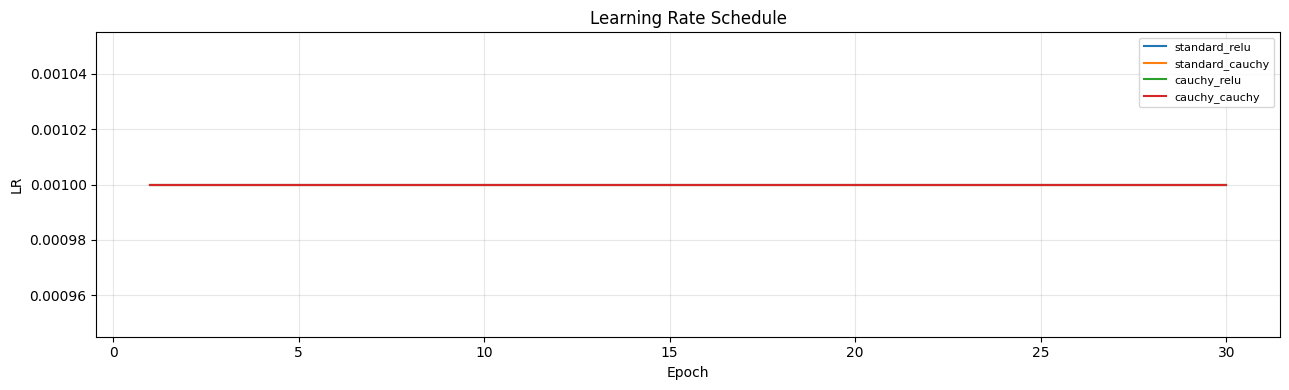

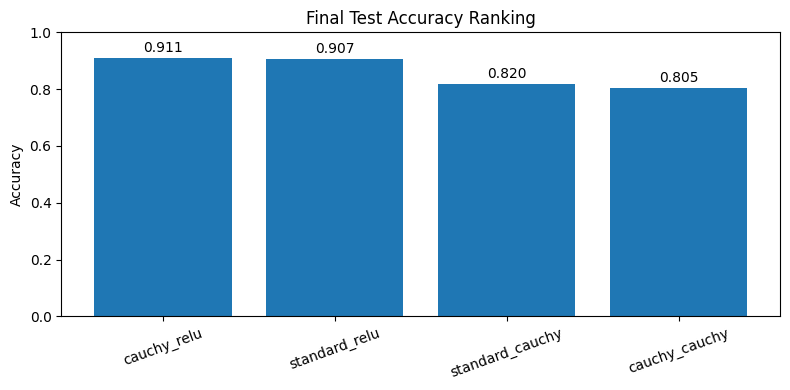

In [8]:
plot_results(results)